In [2]:
import pandas as pd

df = pd.read_csv("data/listings.csv", low_memory = False)#para ler o ficheiro duma vez sem correr o risco de confundir
 
#numero de linhas e colunas
print(df.shape)

#nome, tipo e numero de valores nao nulos em cada coluna 
df.info()

#percentagem de valores em falta por coluna 
missing = (df.isna().mean() * 100).sort_values(ascending = False)
print(missing[missing > 0].round(1).to_string())

print(df["price"].dtype)
print(df["price"].head(10))

(6734, 90)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6734 entries, 0 to 6733
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6734 non-null   int64  
 1   listing_url                                   6734 non-null   object 
 2   scrape_id                                     6734 non-null   int64  
 3   last_scraped                                  6734 non-null   object 
 4   source                                        6734 non-null   object 
 5   name                                          6734 non-null   object 
 6   description                                   6627 non-null   object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   6733 non-null   object 
 9   host_id                                       6734 n

In [3]:
df["price_num"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)

# número de noites da estadia simulada
df["noites"] = (pd.to_datetime(df["price_quote_checkout_date"])
                - pd.to_datetime(df["price_quote_checkin_date"])).dt.days

print(df[["price_num", "price_quote_total_price",
          "price_quote_price_per_night", "noites"]].head(10))
print(df["noites"].value_counts().head())
print(df["price_quote_price_per_night"].describe())

   price_num  price_quote_total_price  price_quote_price_per_night  noites
0    1181.02                 21258.28                      1181.02    18.0
1     822.05                 16441.00                       822.05    20.0
2        NaN                      NaN                          NaN     NaN
3   24910.60                249106.00                     24910.60    10.0
4    1077.87                 32335.99                      1077.87    30.0
5    1746.00                  1746.00                      1746.00     1.0
6     138.82                 12494.13                       138.82    90.0
7     216.00                   216.00                       216.00     1.0
8     127.85                 11506.08                       127.85    90.0
9     216.00                   216.00                       216.00     1.0
noites
1.0     1909
29.0    1012
30.0     897
28.0     498
3.0      434
Name: count, dtype: int64
count      6046.000000
mean        790.401667
std        2699.565444
min     

In [4]:
df["last_scraped"].unique()

array(['2026-06-28', '2026-07-03', '2026-06-29'], dtype=object)

In [5]:
# Ficar apenas com linhas que têm preço
d = df.dropna(subset=["price_num"]).copy()
print(d.shape)
print(d["price_num"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))

#dividir números de noites para ditar preços
d["grupo_noites"] = pd.cut(d["noites"],
                           bins=[0, 1, 7, 27, 31, 1000],
                           labels=["1", "2-7", "8-27", "28-31", "32+"])
#agrupa as linhas por grupo_noites olhando para a coluna price_num
#usei observed para evitar aviso do pandas quando se agrupa categorias
print(d.groupby("grupo_noites", observed=True)["price_num"].agg(["count", "median", "mean"]).round(1))


(6046, 92)
0.010       97.85300
0.050      169.60750
0.250      225.94750
0.500      424.00000
0.750      883.08500
0.950     2187.98000
0.990     4618.87500
0.999    23142.74805
Name: price_num, dtype: float64
              count  median    mean
grupo_noites                       
1              1882   545.0   982.6
2-7            1266   901.5  1267.3
8-27            227   673.9  1174.7
28-31          2535   221.3   407.1
32+             136   120.7   194.6


Linhas: 1882


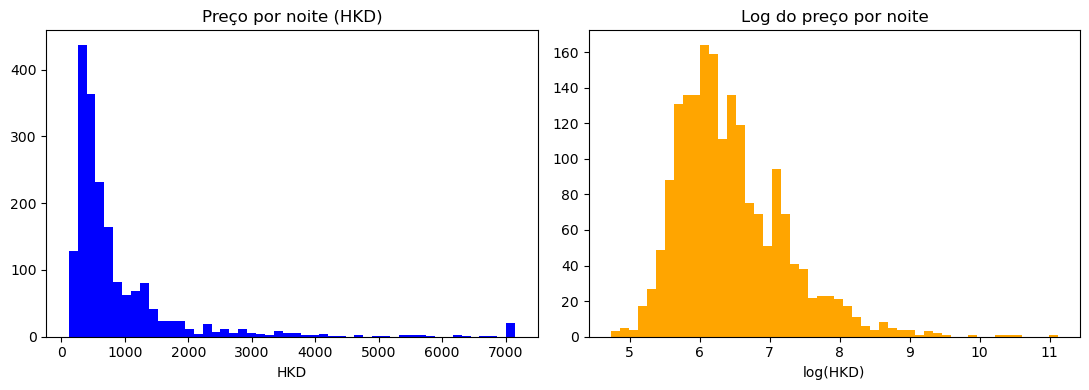

In [6]:
import matplotlib.pyplot as plt
import numpy as np
# Ficar só com estadias de 1 noite
d1 = d[d["noites"] == 1].copy()
print("Linhas:", len(d1))

# Dois histogramas lado a lado
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Preço bruto, cortado no percentil 99 só para o gráfico ser legível
limite = d1["price_num"].quantile(0.99)
ax[0].hist(d1["price_num"].clip(upper=limite), bins=50, color="blue")
ax[0].set_title("Preço por noite (HKD)")
ax[0].set_xlabel("HKD")

# Log do preço
ax[1].hist(np.log(d1["price_num"]), bins=50, color="orange")
ax[1].set_title("Log do preço por noite")
ax[1].set_xlabel("log(HKD)")

plt.tight_layout()
plt.savefig("figures/preco_vs_log_preco.png", dpi=150, bbox_inches="tight")
plt.show()

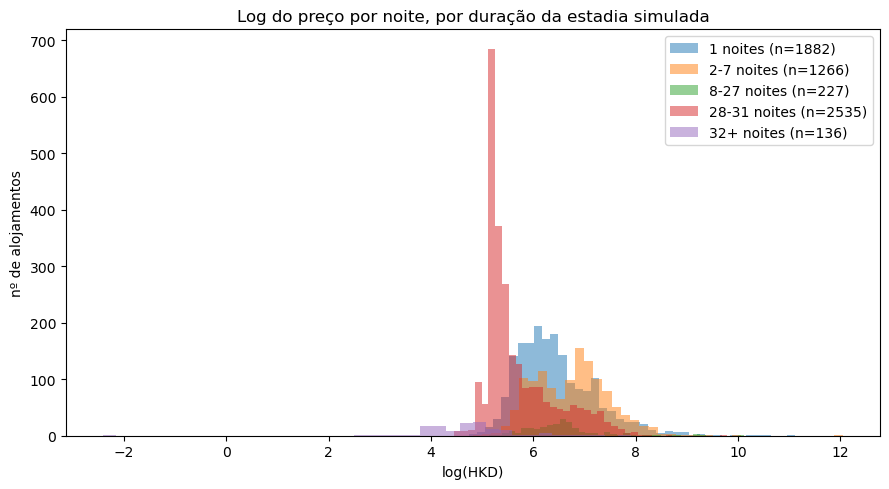

In [7]:
#separar os histogramas do log-preço por grupo de duração

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
#ciclo para percorrer cada grupo da lista

for grupo in ["1", "2-7", "8-27", "28-31", "32+"]:
    #apenas linhas de um dado grupo
    subset = d[d["grupo_noites"] == grupo]
    ax.hist(np.log(subset["price_num"]), bins=40, alpha=0.5, label=f"{grupo} noites (n={len(subset)})")

ax.set_title("Log do preço por noite, por duração da estadia simulada")
ax.set_xlabel("log(HKD)")
ax.set_ylabel("nº de alojamentos")
ax.legend()

plt.tight_layout()
plt.savefig("figures/log_preco_por_duracao.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
#como o preço se relaciona em relação ao tipo de quarto,capacidade e bairro
#preço por tipo de quarto
print(d.groupby("room_type")["price_num"].agg(["count", "median", "mean"]).round(1))

#preco por capacidade
print(d.groupby("accommodates")["price_num"].agg(["count","median","mean"]).round(1))

#Top15 bairros  com mais alojamentos, com o preco mediano
print(d.groupby("neighbourhood_cleansed")["price_num"].agg(["count", "median"]).sort_values("count", ascending=False).head(15).round(1))

                 count  median    mean
room_type                             
Entire home/apt   2209   987.0  1398.2
Hotel room          15   366.0   675.1
Private room      3706   292.1   444.3
Shared room        116   225.0   287.8
              count  median    mean
accommodates                       
1              1628   223.3   327.1
2              2746   393.8   592.8
3               454   664.0  1307.3
4               477   906.9  1150.0
5               155  1256.0  1522.5
6               245  1327.4  1870.4
7                82  1348.3  1815.7
8               124  1386.0  1681.5
9                24  1629.4  1751.6
10               48  1641.2  1732.8
11               14  2187.0  2324.2
12               12  1321.7  4108.9
13                2  1911.8  1911.8
14                5  3021.7  3203.4
15                5  2569.7  3680.0
16               25  2454.0  7171.8
                        count  median
neighbourhood_cleansed               
Yau Tsim Mong            2430   413.0
Wan 

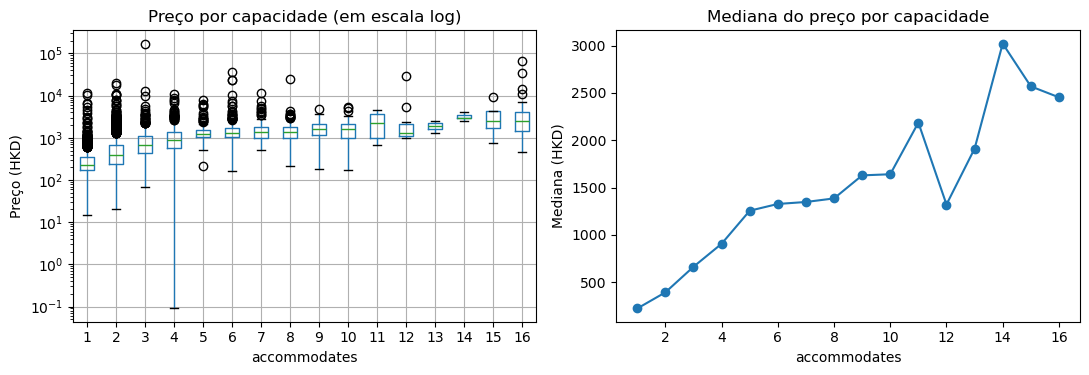

In [9]:
#comparar os preços com a ccapacidade dos alojamentos

fig, ax = plt.subplots(1,2, figsize= (11,4))

# Boxplot do log-preço por capacidade
d.boxplot(column="price_num", by="accommodates", ax=ax[0])
ax[0].set_yscale("log")
ax[0].set_title("Preço por capacidade (em escala log)")
ax[0].set_xlabel("accommodates")
ax[0].set_ylabel("Preço (HKD)")
plt.suptitle("")   # remove o título automático do pandas

# Mediana do preço vs capacidade
mediana_por_cap = d.groupby("accommodates")["price_num"].median()
ax[1].plot(mediana_por_cap.index, mediana_por_cap.values, marker="o")
ax[1].set_title("Mediana do preço por capacidade")
ax[1].set_xlabel("accommodates")
ax[1].set_ylabel("Mediana (HKD)")

plt.tight_layout()
plt.savefig("figures/preco_vs_accommodates.png", dpi=150, bbox_inches="tight")#tight é pra remover as margens brancas
plt.show()



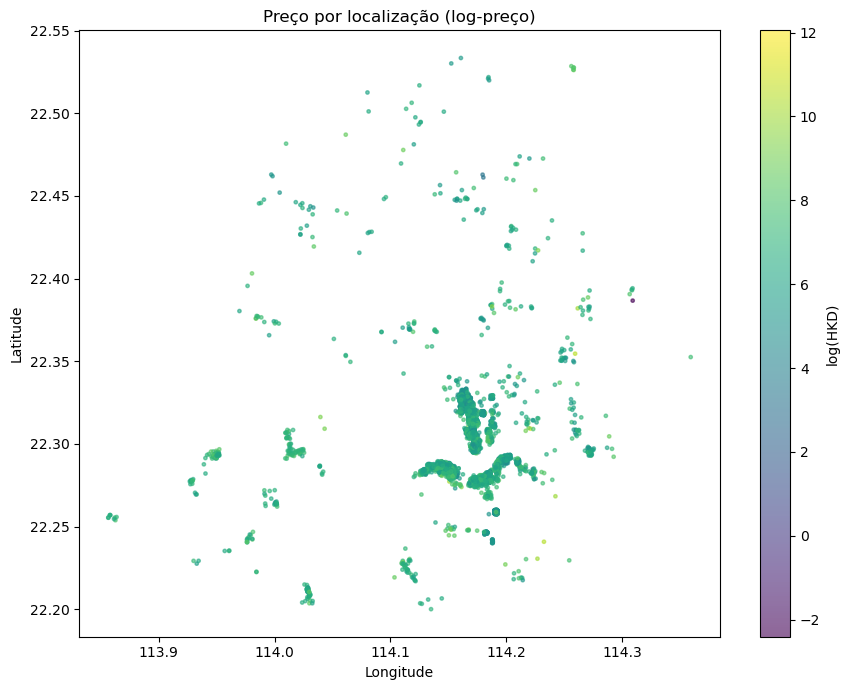

In [10]:
#mapa de preços de acordo com as locs

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

sc = ax.scatter(d["longitude"], d["latitude"], c=np.log(d["price_num"]), s=6, alpha=0.6, cmap="viridis")
ax.set_title("Preço por localização (log-preço)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax, label="log(HKD)")

plt.tight_layout()
plt.savefig("figures/mapa_precos.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
#Estudo de outliers sob log-preço

preco = d["price_num"]
log_preco = np.log(preco)
q1, q3 = log_preco.quantile([0.25,0.75])
iqr = q3-q1
lim_inf_iqr = q1-1.5*iqr
lim_sup_iqr = q3+1.5*iqr
outliers_iqr = (log_preco< lim_inf_iqr)|(log_preco>lim_sup_iqr)
print("____Critério IQR____")
print(f"limites em log: [{lim_inf_iqr:.2f},{lim_sup_iqr:.2f}]")
print(f"Limites em KHD: [{np.exp(lim_inf_iqr):.2f}, {np.exp(lim_sup_iqr):.2f}]")
print(f"nº de outliers:{outliers_iqr.sum()}, média de outliers:{outliers_iqr.mean()*100:.1f}%")

____Critério IQR____
limites em log: [3.38,8.83]
Limites em KHD: [29.24, 6823.30]
nº de outliers:40, média de outliers:0.7%


In [12]:
#Estudo de outlieres pela mediana dos desvios absolutos
mediana = log_preco.median()
mad = (log_preco-mediana).abs().median()
#transformacao para z robusto
z_robusto = (log_preco - mediana).abs() / (1.4826 * mad)

#como saber se é outlier
outliers_mad = z_robusto > 3
lim_inf_mad = mediana - 3*1.4826 * mad
lim_sup_mad = mediana + 3*1.4826 * mad
print("___Critério MAD, z>3___")
print(f"Limites em log: [{lim_inf_mad:.2f},{lim_sup_mad:.2f}]")
print(f"Limites em HKD: [{np.exp(lim_inf_mad):.2f}, {np.exp(lim_sup_mad):.2f}]")
print(f"nº de outliers: {outliers_mad.sum()}, Média de outliers:{outliers_mad.mean()*100:.2f}%")



___Critério MAD, z>3___
Limites em log: [3.05,9.05]
Limites em HKD: [21.19, 8485.17]
nº de outliers: 28, Média de outliers:0.46%


In [13]:
#concordancia entre os dois
print("\n=== Concordância ===")
print(f"Detetados pelos dois:      {(outliers_iqr & outliers_mad).sum()}")
print(f"Só pelo IQR:               {(outliers_iqr & ~outliers_mad).sum()}")
print(f"Só pelo MAD:               {(outliers_mad & ~outliers_iqr).sum()}")
print(f"União (por pelo menos um): {(outliers_iqr | outliers_mad).sum()}")


=== Concordância ===
Detetados pelos dois:      28
Só pelo IQR:               12
Só pelo MAD:               0
União (por pelo menos um): 40


In [14]:

d["outlier_iqr"] = outliers_iqr
d["outlier_mad"] = outliers_mad

# Ver os 10 preços mais baixos e os 10 mais altos, com contexto
colunas_ver = ["price_num", "room_type", "accommodates",
               "neighbourhood_cleansed", "noites",
               "outlier_iqr", "outlier_mad"]

print("=== 10 mais baratos ===")
#precos mais baixos
print(d.nsmallest(10, "price_num")[colunas_ver].to_string())

print("\n=== 10 mais caros ===")
#precos mais caros
print(d.nlargest(10, "price_num")[colunas_ver].to_string())

=== 10 mais baratos ===
      price_num        room_type  accommodates neighbourhood_cleansed  noites  outlier_iqr  outlier_mad
2429       0.09  Entire home/apt             4               Sai Kung   300.0         True         True
3125      14.51     Private room             1                Eastern   291.0         True         True
3238      20.00     Private room             2           Sham Shui Po   259.0         True         True
1996      25.05  Entire home/apt             2                 Tai Po   365.0         True        False
1995      25.86  Entire home/apt             2                 Tai Po   365.0         True        False
2724      29.06     Private room             2                Eastern   365.0         True        False
2638      34.16  Entire home/apt             1          Yau Tsim Mong   258.0        False        False
2566      35.22  Entire home/apt             4           Sham Shui Po   365.0        False        False
4644      44.15     Private room        

In [15]:
# Marcar cada linha como outlier de preço (união dos dois critérios)
d["outlier_preco"] = d["outlier_iqr"] | d["outlier_mad"]

# Por room_type
print("____Outliers de preço por room_type____")
print(d.groupby("room_type")["outlier_preco"]
        .agg(["sum", "mean"])
        .rename(columns={"sum": "n_outliers", "mean": "taxa"})
        .assign(taxa=lambda x: (x["taxa"] * 100).round(2))
        .sort_values("n_outliers", ascending=False))

# Por bairro (só os que têm outliers)
print("\n____Outliers de preço por bairro (só os que têm)____")
por_bairro = (d.groupby("neighbourhood_cleansed")["outlier_preco"]
                .agg(["sum", "count", "mean"])
                .rename(columns={"sum": "n_outliers",
                                 "count": "total",
                                 "mean": "taxa"}))
por_bairro["taxa"] = (por_bairro["taxa"] * 100).round(2)
print(por_bairro[por_bairro["n_outliers"] > 0]
        .sort_values("n_outliers", ascending=False))

____Outliers de preço por room_type____
                 n_outliers  taxa
room_type                        
Entire home/apt          29  1.31
Private room             11  0.30
Hotel room                0  0.00
Shared room               0  0.00

____Outliers de preço por bairro (só os que têm)____
                        n_outliers  total  taxa
neighbourhood_cleansed                         
Central & Western               10   1034  0.97
Southern                         5    115  4.35
Yau Tsim Mong                    4   2430  0.16
Wan Chai                         3   1283  0.23
Sai Kung                         3     93  3.23
Eastern                          3    252  1.19
Tai Po                           2     38  5.26
Kwun Tong                        2     23  8.70
Islands                          2    254  0.79
Sha Tin                          2     36  5.56
North                            1     21  4.76
Sham Shui Po                     1    162  0.62
Tuen Mun                      

In [16]:
# --- minimum_nights ---
print("=== minimum_nights: distribuição ===")
print(d["minimum_nights"].describe().round(1))
print("\nValores mais comuns:")
print(d["minimum_nights"].value_counts().head(10))

# --- accommodates ---
print("\n=== accommodates: distribuição ===")
print(d["accommodates"].describe().round(1))
print("\nDistribuição:")
print(d["accommodates"].value_counts().sort_index())

=== minimum_nights: distribuição ===
count    6046.0
mean       16.5
std        26.8
min         1.0
25%         1.0
50%         5.0
75%        29.0
max       365.0
Name: minimum_nights, dtype: float64

Valores mais comuns:
minimum_nights
1     2057
29    1003
30     868
3      405
28     400
2      384
31     179
5      169
4      100
7       96
Name: count, dtype: int64

=== accommodates: distribuição ===
count    6046.0
mean        2.6
std         2.1
min         1.0
25%         1.0
50%         2.0
75%         3.0
max        16.0
Name: accommodates, dtype: float64

Distribuição:
accommodates
1     1628
2     2746
3      454
4      477
5      155
6      245
7       82
8      124
9       24
10      48
11      14
12      12
13       2
14       5
15       5
16      25
Name: count, dtype: int64


In [17]:
#mapa para missing values
missing_pct = (d.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct.round(1).to_string())

neighborhood_overview           100.0
host_since                      100.0
host_verifications              100.0
host_total_listings_count       100.0
host_thumbnail_url              100.0
host_response_time              100.0
host_acceptance_rate            100.0
host_response_rate              100.0
host_neighbourhood              100.0
calendar_updated                100.0
neighbourhood_group_cleansed    100.0
license                         100.0
instant_bookable                100.0
neighbourhood                   100.0
review_scores_accuracy           45.3
review_scores_cleanliness        45.3
review_scores_communication      45.3
review_scores_location           45.3
review_scores_value              45.3
review_scores_rating             45.2
review_scores_checkin            45.2
first_review                     45.2
reviews_per_month                45.2
last_review                      45.2
bedrooms                         44.8
host_about                       35.7
host_locatio

In [18]:
# Colunas com missing significativos
colunas_missing = missing_pct[missing_pct > 5].index.tolist()
print("Colunas com >5% missing:", colunas_missing)

# Matriz de "quem falha ao mesmo tempo"
# 1 = a linha tem missing nesta coluna, 0 = tem valor
matriz = d[colunas_missing].isna().astype(int)

# Correlação entre os padrões de missing
corr = matriz.corr()
print("\nCorrelação dos padrões de missing:")
print(corr.round(2).to_string())

Colunas com >5% missing: ['neighborhood_overview', 'host_since', 'host_verifications', 'host_total_listings_count', 'host_thumbnail_url', 'host_response_time', 'host_acceptance_rate', 'host_response_rate', 'host_neighbourhood', 'calendar_updated', 'neighbourhood_group_cleansed', 'license', 'instant_bookable', 'neighbourhood', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'review_scores_rating', 'review_scores_checkin', 'first_review', 'reviews_per_month', 'last_review', 'bedrooms', 'host_about', 'host_location', 'bathrooms']

Correlação dos padrões de missing:
                              neighborhood_overview  host_since  host_verifications  host_total_listings_count  host_thumbnail_url  host_response_time  host_acceptance_rate  host_response_rate  host_neighbourhood  calendar_updated  neighbourhood_group_cleansed  license  instant_bookable  neighbourhood  review_scores_accuracy  review_scores_cl

In [19]:
# Ver alguns exemplos coluna amenities
print("=== Primeiros valores ===")
for i in range(3):
    print(f"\nLinha {i}:")
    print(d["amenities"].iloc[i][:300], "...")

# Tipo dos valores
print("\n=== Tipo ===")
print(type(d["amenities"].iloc[0]))

=== Primeiros valores ===

Linha 0:
["Heating", "Cooking basics", "Lockbox", "Shampoo", "Essentials", "Refrigerator", "Free washer \u2013 In unit", "Window AC unit", "55 inch HDTV with standard cable", "Iron", "Children\u2019s dinnerware", "Hair dryer", "Kitchen", "Dishes and silverware", "Dedicated workspace", "Self check-in", "Crib" ...

Linha 1:
["Air conditioning", "Smoke alarm", "Essentials", "Cooking basics", "Hot water", "TV with standard cable", "Hangers", "Fire extinguisher", "Dishes and silverware", "Wifi", "Hair dryer", "Refrigerator", "Shampoo", "Dedicated workspace", "Lockbox", "Microwave", "Crib", "Kitchen", "Self check-in", "Hea ...

Linha 2:
["Heating", "Elevator", "Doorman", "Free parking on premises", "Exercise equipment", "Kitchen", "Dishes and silverware", "Dedicated workspace", "Washer", "Refrigerator", "Wifi", "Air conditioning", "Breakfast", "Children\u2019s dinnerware", "Dryer", "TV with standard cable"] ...

=== Tipo ===
<class 'str'>


In [20]:
import json

# Converter cada linha de texto em lista Python
d["amenities_lista"] = d["amenities"].apply(json.loads)

# Contar quantas amenities cada alojamento tem
d["n_amenities"] = d["amenities_lista"].apply(len)

# Distribuição
print("=== Nº de amenities por alojamento ===")
print(d["n_amenities"].describe().round(1))

# Contar quantas vezes cada amenity aparece no dataset todo
from collections import Counter

todas = Counter()
for lista in d["amenities_lista"]:
    todas.update(lista)

print(f"\n=== Total de amenities distintas: {len(todas)} ===")
print("\n=== Top 30 mais comuns ===")
for amenity, contagem in todas.most_common(30):
    pct = contagem / len(d) * 100
    print(f"  {contagem:>5}  ({pct:5.1f}%)  {amenity}")

=== Nº de amenities por alojamento ===
count    6046.0
mean       17.5
std        12.9
min         0.0
25%         7.0
50%        14.0
75%        25.0
max        76.0
Name: n_amenities, dtype: float64

=== Total de amenities distintas: 871 ===

=== Top 30 mais comuns ===
   5688  ( 94.1%)  Wifi
   5397  ( 89.3%)  Air conditioning
   4071  ( 67.3%)  Kitchen
   3427  ( 56.7%)  Hot water
   3367  ( 55.7%)  Hangers
   3095  ( 51.2%)  Washer
   3063  ( 50.7%)  Hair dryer
   3045  ( 50.4%)  TV
   2679  ( 44.3%)  Shampoo
   2611  ( 43.2%)  Elevator
   2593  ( 42.9%)  Iron
   2501  ( 41.4%)  Essentials
   2377  ( 39.3%)  Bed linens
   2259  ( 37.4%)  Smoke alarm
   2198  ( 36.4%)  Refrigerator
   2181  ( 36.1%)  Fire extinguisher
   2180  ( 36.1%)  Self check-in
   2037  ( 33.7%)  Long term stays allowed
   2028  ( 33.5%)  Dedicated workspace
   1878  ( 31.1%)  Shower gel
   1849  ( 30.6%)  Dishes and silverware
   1767  ( 29.2%)  Cooking basics
   1757  ( 29.1%)  Hot water kettle
   1742  ( 2

In [21]:
# ---- 1. Definir as 10 categorias como listas de palavras-chave ----
# Cada amenity é atribuída à primeira categoria em que "encaixa"
# (categorias exclusivas), na ordem em que estão listadas.

categorias = {
    "luxo": ["pool", "hot tub", "sauna", "gym", "doorman", "concierge",
             "bbq grill", "fireplace", "piano", "bidet"],
    "vista_exterior": ["balcony", "patio", "garden", "backyard",
                        "view", "beach access"],
    "cozinha_completa": ["oven", "stove", "dishwasher", "coffee maker",
                          "toaster", "blender", "rice maker", "wine glass",
                          "barware"],
    "familia": ["crib", "high chair", "children", "baby", "board game"],
    "seguranca": ["smoke alarm", "carbon monoxide", "fire extinguisher",
                   "first aid", "lock on bedroom", "safe", "security camera"],
    "acessibilidade": ["elevator", "step-free", "wide entrance",
                        "ground floor", "accessible"],
    "estacionamento": ["parking", "ev charger"],
    "servicos_host": ["self check-in", "lockbox", "keypad", "smart lock",
                       "building staff", "cleaning available",
                       "long term stays", "luggage dropoff"],
    "tecnologia": ["tv", "hdtv", "cable", "sound system", "game console",
                    "books and reading", "ethernet", "workspace"],
    "basicas": ["wifi", "air conditioning", "heating", "hot water",
                 "kitchen", "refrigerator", "washer", "dryer", "iron",
                 "hangers", "bed linens", "essentials", "shampoo",
                 "hair dryer", "shower gel", "cooking basics",
                 "dishes", "microwave", "kettle", "toilet paper", "towel"],
}

# ---- 2. Função que classifica UMA amenity numa categoria ----
def classificar(amenity):
    a = amenity.lower()
    for cat, palavras in categorias.items():
        for palavra in palavras:
            if palavra in a:
                return cat
    return "outras"

# ---- 3. Criar as features de contagem por categoria ----
# Para cada alojamento, contar quantas amenities caem em cada categoria.
def contar_por_categoria(lista_amenities):
    contagens = {cat: 0 for cat in categorias}
    contagens["outras"] = 0
    for a in lista_amenities:
        cat = classificar(a)
        contagens[cat] += 1
    return contagens

contagens_df = d["amenities_lista"].apply(contar_por_categoria).apply(pd.Series)
contagens_df.columns = ["amen_" + c for c in contagens_df.columns]

# Adicionar ao dataframe
d = pd.concat([d, contagens_df], axis=1)

# ---- 4. Binárias de luxo específicas ----
def tem(lista, palavras):
    lista_lower = [a.lower() for a in lista]
    return int(any(p in a for a in lista_lower for p in palavras))

d["tem_piscina"] = d["amenities_lista"].apply(lambda x: tem(x, ["pool"]))
d["tem_jacuzzi"] = d["amenities_lista"].apply(lambda x: tem(x, ["hot tub"]))
d["tem_gym"] = d["amenities_lista"].apply(lambda x: tem(x, ["gym"]))
d["tem_doorman"] = d["amenities_lista"].apply(lambda x: tem(x, ["doorman"]))
d["tem_vista_mar"] = d["amenities_lista"].apply(lambda x: tem(x, ["sea view", "ocean view"]))
d["tem_vista_cidade"] = d["amenities_lista"].apply(lambda x: tem(x, ["city skyline"]))

# ---- 5. Ver o resultado ----
print("=== Contagens médias por categoria ===")
print(contagens_df.mean().round(2).sort_values(ascending=False))

print("\n=== Binárias de luxo (% de alojamentos que têm) ===")
for col in ["tem_piscina", "tem_jacuzzi", "tem_gym", "tem_doorman",
            "tem_vista_mar", "tem_vista_cidade"]:
    print(f"  {col:20}  {d[col].mean()*100:5.1f}%")

=== Contagens médias por categoria ===
amen_basicas             8.61
amen_outras              2.96
amen_seguranca           1.47
amen_servicos_host       1.35
amen_tecnologia          1.08
amen_cozinha_completa    0.68
amen_acessibilidade      0.43
amen_luxo                0.28
amen_vista_exterior      0.24
amen_familia             0.21
amen_estacionamento      0.17
dtype: float64

=== Binárias de luxo (% de alojamentos que têm) ===
  tem_piscina             4.7%
  tem_jacuzzi             3.5%
  tem_gym                 3.9%
  tem_doorman             3.8%
  tem_vista_mar           1.4%
  tem_vista_cidade        2.6%
